In [2]:
from solver_selection_thm.thm_physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt
from load_experiments_data import load_experiments_data_thm

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


In [3]:
import pickle
from itertools import count
from copy import copy


# RUNS = [20, 21, 22, 23, 24]
RUNS_RANDOM = [31, 32, 33, 40, 41, 42]
# RUNS = [20,21,22]

# sim_data, perf_data, solver_selector = load_experiments_data_thm(runs=RUNS, random_selection=False)
sim_data_random, perf_data_random, solver_selector = load_experiments_data_thm(runs=RUNS_RANDOM, random_selection=True)

FileNotFoundError: [Errno 2] No such file or directory: '../stats/thm_solver_space_scheme_run_40.pkl'

In [ ]:
from collections import defaultdict
import pandas as pd


def make_pandas(sim_data, perf_data, seq_ids):
    sim_data_dict = defaultdict(lambda: [])
    perf_data_dict = defaultdict(lambda: [])
    for seq_id, data_simulations, solver_selection_history_seq in zip(
        seq_ids, sim_data, perf_data
    ):
        sim_idx = -1
        for data_row in data_simulations:
            for data in data_row:
                sim_idx += 1

                for ts_idx, ts in enumerate(data):
                    for ls_idx, ls in enumerate(ts.linear_solves):
                        sim_data_dict["seq_id"].append(seq_id)
                        sim_data_dict["sim_idx"].append(sim_idx)
                        sim_data_dict["ts_idx"].append(ts_idx)
                        sim_data_dict["ls_idx"].append(ls_idx)
                        sim_data_dict["real_solve_time"].append(ls.linear_solve_time)
                        sim_data_dict["krylov_iters"].append(ls.krylov_iters)
                        sim_data_dict["petsc_converged_reason"].append(
                            ls.petsc_converged_reason
                        )
                        sim_data_dict["cfl"].append(ls.cfl)

        solver_selection_history = None
        for x in solver_selection_history_seq:
            if x is not None:
                solver_selection_history = x
        for reward_idx in range(len(solver_selection_history.reward)):
            perf_data_dict["seq_id"].append(seq_id)
            perf_data_dict["sim_idx"].append(sim_idx)
            perf_data_dict["reward"].append(
                solver_selection_history.reward[reward_idx]
            )
            perf_data_dict["expectation"].append(
                solver_selection_history.expectation[reward_idx]
            )
            perf_data_dict["decision_idx"].append(
                solver_selection_history.decision_idx[reward_idx]
            )
            perf_data_dict["features"].append(
                solver_selection_history.features[reward_idx]
            )
    return pd.DataFrame(data=sim_data_dict), pd.DataFrame(data=perf_data_dict)


# ALL_RUNS = [str(x) for x in RUNS] + [f"R{x}" for x in RUNS_RANDOM]
# df_sim, df_perf = make_pandas(
#     sim_data=sim_data + sim_data_random,
#     perf_data=perf_data + perf_data_random,
#     seq_ids=ALL_RUNS,
# )
ALL_RUNS = [f"R{x}" for x in RUNS_RANDOM]
df_sim, df_perf = make_pandas(
    sim_data=sim_data_random,
    perf_data=perf_data_random,
    seq_ids=ALL_RUNS,
)

df_sim

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl
0,R31,0,0,0,12.769563,42,2,2.759354e-16
1,R31,0,0,1,12.079205,47,2,5.925187e-03
2,R31,0,0,2,36.754681,99,2,5.928433e-03
3,R31,0,0,3,5.324022,38,2,5.928433e-03
4,R31,0,1,0,13.174792,84,2,5.928433e-03
...,...,...,...,...,...,...,...,...
11881,R33,24,52,1,4.871519,40,2,1.117042e+01
11882,R33,24,52,2,5.342534,74,2,1.117042e+01
11883,R33,24,53,0,50.415925,59,2,6.270927e+00
11884,R33,24,53,1,22.838623,76,2,6.270923e+00


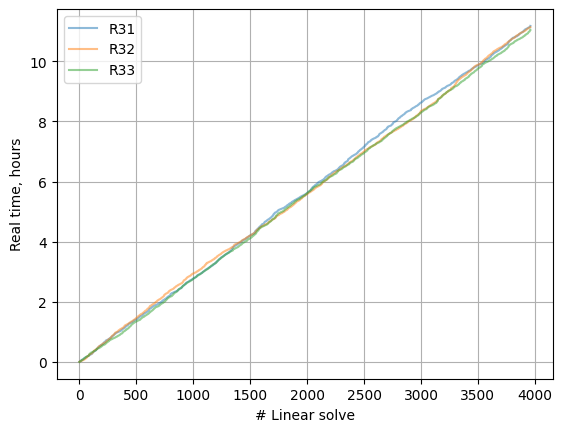

In [ ]:
FAIL_REWARD = -100
HOUR = 60 * 60
DAY = 24 * HOUR

for seq_id in ALL_RUNS:
    seq_idx = np.array(df_sim.seq_id == seq_id)
    time = np.array(df_sim.real_solve_time)[seq_idx]
    plt.plot(np.cumsum(time) / HOUR, label=seq_id, alpha=0.5)
plt.legend()
plt.ylabel('Real time, hours')
plt.xlabel('# Linear solve')
plt.grid()
plt.savefig('thm_runtime.png')

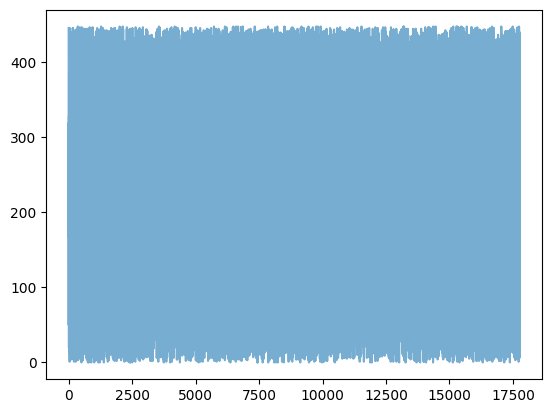

In [7]:
decision_id = np.array(df_perf.decision_idx)
_ = plt.plot(decision_id, label='Decision idx', alpha=0.6)

448


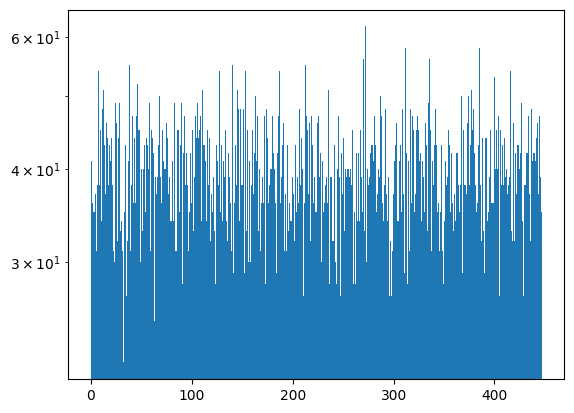

In [8]:
num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]
print(num_solvers)
_ = plt.hist(decision_id, bins=num_solvers, log=True)

In [9]:
FAIL_REWARD = -100
num_success = (df_perf.reward > FAIL_REWARD).sum()
print(num_success, df_perf.shape[0])
print(num_success / df_perf.shape[0])

11886 17762
0.6691813984911609


* Classifier - test on a SINGLE sequence. Random and simulation.
* Oracle - Use all data.
* Regressor cv on all data

In [10]:
X = np.stack(df_perf.features)
y = np.array(df_perf.reward)
success = y > FAIL_REWARD
Xsuccess = X[success]
ysuccess = y[success]
ycat = success
print(Xsuccess.shape, ysuccess.shape)

(11886, 35) (11886,)


In [11]:
from typing import Literal

classification_case: Literal["all", "one_seq", "random"] = "all"
if classification_case == "all":
    X_classification = X
    y_classification = ycat
else:
    raise ValueError(classification_case)

print(f"{classification_case = }", X_classification.shape, y_classification.shape)
print('success %:', y_classification.sum() / y_classification.size * 100)

classification_case = 'all' (17762, 35) (17762,)
success %: 66.91813984911609


In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier
from sklearn.ensemble import GradientBoostingClassifier


classifier = SuccessClassifier()
# classifier = GradientBoostingClassifier()

scoring = ("accuracy", "f1")
cv_results = cross_validate(
    classifier,
    X_classification,
    y_classification,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
)
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_classifier_offline = cv_results["estimator"][np.argmax(cv_results["test_f1"])]
best_classifier_offline

accuracy
Train scores: [0.91793933 0.91948765 0.92814919 0.91731175 0.92744546]
Test scores: [0.91866029 0.91415705 0.92652027 0.9161036  0.92173423]
Mean Train: 0.9220666773678099
Mean Test: 0.9194350891138818

f1
Train scores: [0.93618651 0.93744532 0.94452594 0.93538631 0.94384226]
Test scores: [0.93677532 0.93307    0.9432732  0.93439014 0.93922169]
Mean Train: 0.9394772685715903
Mean Test: 0.9373460701326446



,classifier,SGDClassifier...ndom_state=42)
,random_state,42
,loss,'log_loss'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0


2. Training offline model with cross-validation and comparing its

In [16]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

def make_oracle_regressor():
    return GradientBoostingRegressor(random_state=42)
oracle = make_oracle_regressor()

scoring = ("r2", "neg_mean_absolute_error", "neg_mean_squared_error")
cv_results = cross_validate(
    oracle,
    Xsuccess.clip(-1e10, 1e10),
    ysuccess,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
    n_jobs=1,
)

In [17]:
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_regressor_offline = cv_results["estimator"][np.argmax(cv_results["test_r2"])]
best_regressor_offline

r2
Train scores: [0.93518054 0.93473246 0.93252316 0.93333247 0.92861851]
Test scores: [0.91776326 0.91851595 0.93192303 0.93143792 0.94195936]
Mean Train: 0.9328774285764094
Mean Test: 0.9283199034885244

neg_mean_absolute_error
Train scores: [-0.05902331 -0.05974711 -0.05935881 -0.05891127 -0.05972948]
Test scores: [-0.0623975  -0.06011454 -0.06075468 -0.06096009 -0.06032689]
Mean Train: -0.05935399702693469
Mean Test: -0.06091073784222467

neg_mean_squared_error
Train scores: [-0.00577306 -0.00585378 -0.00585121 -0.00580792 -0.00589039]
Test scores: [-0.00648526 -0.00621958 -0.00600828 -0.00593918 -0.00608562]
Mean Train: -0.00583527298639031
Mean Test: -0.006147585828319331



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [20]:
np.std(ysuccess)

0.2949972006487219

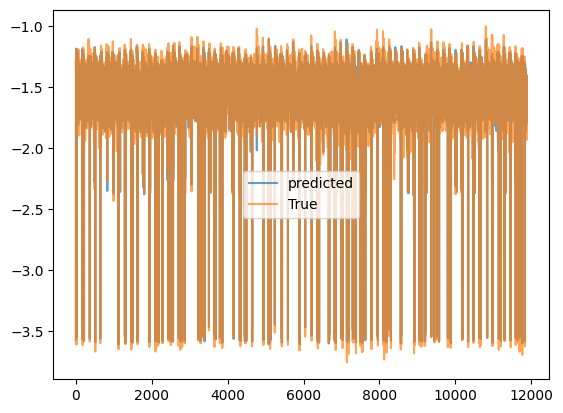

In [21]:
plt.plot(best_regressor_offline.predict(Xsuccess.clip(-1e10, 1e10)), label='predicted', alpha=0.7)
plt.plot(ysuccess, label='True', alpha=0.7)
plt.legend()

Offline ranking score

In [ ]:
from typing import Literal
ranking_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
if ranking_case == 'all':
    X_ranking = Xsuccess
    y_ranking = ysuccess
elif ranking_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "22") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
elif ranking_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R8") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
else:
    raise ValueError(ranking_case)

print(f'{ranking_case = }', X_ranking.shape, y_ranking.shape)

ranking_case = 'one_seq' (3962, 35) (3962,)


In [ ]:
from sklearn.model_selection import KFold
from solver_selection_thm.performance_predictor import RewardRegressor
from tqdm import tqdm

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)

oracle = make_oracle_regressor()
oracle.fit(Xsuccess.clip(-1e10, 1e10), ysuccess)  # oracle trains on full data anyway

kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xranking_features = X_ranking[:, : -all_solvers.shape[1]]  # removing solvers encoding

data_k_fold = []

for train_set, test_set in kf.split(X_ranking):
    estimator = RewardRegressor()
    estimator.fit(X_ranking[train_set], ysuccess[train_set])

    data_this = []
    data_k_fold.append(data_this)

    # ranking
    for test_idx in tqdm(test_set):
        x_to_predict = stack_features_solvers(Xranking_features[test_idx], all_solvers)

        # online
        ypred = estimator.predict(x_to_predict)

        # offline
        yoracle = oracle.predict(x_to_predict.clip(-1e10, 1e10))

        data_this.append({'yoracle': yoracle, 'ypred': ypred})

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
def top_1_normalized_score(ypred, ytrue):
    i = np.argmax(ypred)
    s = ytrue[i]
    ymin, ymax = np.min(ytrue), np.max(ytrue)
    if ymax == ymin:
        return 0.0  # degenerate case: all ytrue values are equal
    else:
        return -1.0 + 2.0 * (s - ymin) / (ymax - ymin)
    
def top_eps_accuracy(ypred, ytrue, eps=1e-3):
    i = np.argmax(ypred)
    return abs(ytrue[i] - np.max(ytrue)) <= eps

In [ ]:
mean_NTS = [np.mean([top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_test]) for data_test in data_k_fold]
print(mean_NTS)
np.mean(mean_NTS)

[0.893266019134829, 0.9229699026427229, 0.8941288790808054, 0.8948353417430763, 0.8937031830460168]


0.8997806651294902

In [ ]:
for eps in [1e-2, 3e-2, 4e-2, 1e-1, 3e-1, 4e-1]:
    mean_topeps = [np.mean([top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_test]) for data_test in data_k_fold]
    mean_topeps = np.mean(mean_topeps)
    print(f'{eps = :.0e}, {mean_topeps = :.2f}')

eps = 1e-02, mean_topeps = 0.00
eps = 3e-02, mean_topeps = 0.00
eps = 4e-02, mean_topeps = 0.01
eps = 1e-01, mean_topeps = 0.29
eps = 3e-01, mean_topeps = 1.00
eps = 4e-01, mean_topeps = 1.00


Incremental learning

In [ ]:
class NoExploration:

    def should_explore(self) -> bool:
        return False
    

class EpsGreedyExploration:

    def __init__(self, eps1: float, eps2: float) -> None:
        self.eps1 = eps1
        self.eps2 = eps2

    def should_explore(self) -> bool:
        result = np.random.random() < self.eps1
        self.eps1 *= self.eps2
        return result


class TwoEstimators:

    def __init__(self, classifier, regressor, exploration = None, is_incr_learn: bool = True, ratio_offline_fit: float = 1, sticking_to_one: ):
        self.classifier = classifier
        self.regressor = regressor
        self.is_incr_learn = is_incr_learn
        self.ratio_offline_fit = ratio_offline_fit
        self.exploration = exploration if exploration is not None else NoExploration()

    def fit(self, X, y):
        if self.ratio_offline_fit < 1:
            n_true = int(y.size) * self.ratio_offline_fit
            idx_fit = np.array([True] * n_true + [False] * (y.size - n_true ))
            np.random.seed(42)
            np.random.shuffle(idx_fit)
            X = X[idx_fit]
            y = y[idx_fit]
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        if not self.is_incr_learn:
            return
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        if self.exploration.should_explore():
            reward_estimate = np.full(X.shape[0], -FAIL_REWARD, dtype=float)
            reward_estimate += np.random.random(X.shape[0]) 
            return reward_estimate

        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return reward_estimate

In [ ]:
from typing import Literal
incremental_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
expectations = None
if incremental_case == 'all':
    Xincr = X
    yincr = y
elif incremental_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "22"))
    Xincr = X[filter_]
    yincr = y[filter_]
    expectations = np.array(df_perf.expectation)[filter_][num_solvers:]
elif incremental_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R8"))
    Xincr = X[filter_]
    yincr = y[filter_]
else:
    raise ValueError(incremental_case)

Xoffline = Xincr[:num_solvers]
yoffline = yincr[:num_solvers]
Xonline = Xincr[num_solvers:]
yonline = yincr[num_solvers:]

print(f'{incremental_case = }', Xincr.shape, Xoffline.shape, Xonline.shape)

incremental_case = 'one_seq' (4107, 35) (448, 35) (3659, 35)


Sanity check -- the predictor here does exactly the same result on the same data as in the real sim.

In [ ]:
if expectations is not None:
    regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
    regressor_online.fit(Xoffline, yoffline)

    reward_expected = []

    for Xbatch, ybatch in zip(tqdm(Xonline), yonline):
        # online
        ypred_expected = regressor_online.predict(Xbatch.reshape(1, -1))

        # feedback
        solve_time = np.exp(-ybatch)
        regressor_online.partial_fit(Xbatch.reshape(1, -1), [ybatch])

        # saving stats
        reward_expected.append(ypred_expected.item())

    assert np.allclose(reward_expected, expectations, rtol=1e-10, atol=1e-10)

100%|██████████| 3659/3659 [00:07<00:00, 501.42it/s]


In [ ]:
model_case: Literal[
    "original",
    "disable_incr",
    "limit_offline",
    "eps_greedy",
    "sticking_to_one",
    "batch",
    "nonlinear_nn",
    "forest",
] = "original"
if model_case == "original":
    regressor_online = TwoEstimators(
        classifier=SuccessClassifier(), regressor=RewardRegressor()
    )
elif model_case == "disable_incr":
    regressor_online = TwoEstimators(
        classifier=SuccessClassifier(),
        regressor=RewardRegressor(),
        is_incr_learn=False,
    )
elif model_case == "limit_offline":
    regressor_online = TwoEstimators(
        classifier=SuccessClassifier(),
        regressor=RewardRegressor(),
        ratio_offline_fit=0.5,
    )
elif model_case == "eps_greedy":
    regressor_online = TwoEstimators(
        classifier=SuccessClassifier(),
        regressor=RewardRegressor(),
        exploration=EpsGreedyExploration(eps1=0.1, eps2=0.1),
    )
elif model_case == 'sticking_to_one'

In [ ]:
from time import time

oracle = TwoEstimators(
    classifier=SuccessClassifier(), regressor=make_oracle_regressor()
)
oracle.fit(X.clip(-1e10, 1e10), y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding


regressor_online.fit(Xoffline, yoffline)
# regressor_online.fit(Xoffline[:10], yoffline[:10])

data_incremental = []

for Xfeature in tqdm(Xonline_features):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    tpred = time()
    predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    tpred = time() - tpred

    # offline
    predictions_offline = best_regressor_offline.predict(x_to_predict.clip(-1e10, 1e10))

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    tfeedback = time()
    if DO_INCR_LEARN:
        regressor_online.partial_fit(X_feedback, [y_feedback])
    tfeedback = time() - tfeedback

    # saving stats
    data_incremental.append(
        {
            "ypred": predictions_online,
            "yoracle": predictions_offline,
            "tpred": tpred,
            "tfeedback": tfeedback,
        }
    )

100%|██████████| 3659/3659 [00:03<00:00, 1063.67it/s]


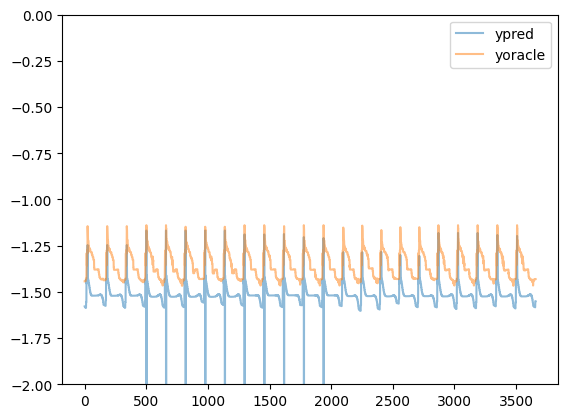

In [ ]:
plt.plot([max(x["ypred"]) for x in data_incremental], label="ypred", alpha=0.5)
plt.plot([max(x["yoracle"]) for x in data_incremental], label="yoracle", alpha=0.5)
plt.ylim(-2, -0)
plt.legend()

1.69


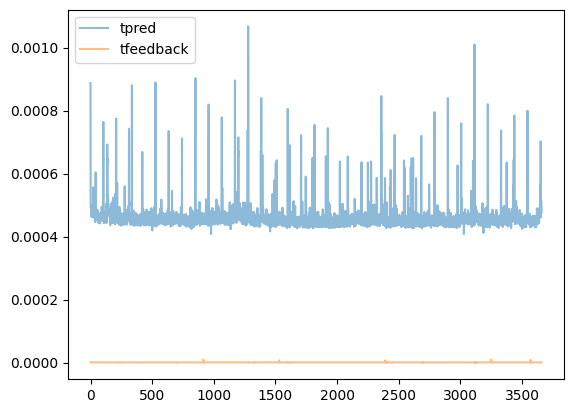

In [ ]:
tpred = np.array([(x["tpred"]) for x in data_incremental])
tfeedback = np.array([(x["tfeedback"]) for x in data_incremental])
plt.plot(tpred, label="tpred", alpha=0.5)
plt.plot(tfeedback, label="tfeedback", alpha=0.5)
plt.legend()
print(f'{np.sum(tpred) + np.sum(tfeedback):.2f}')

$R = -\log(T)$

$T = \exp(-R)$

In [ ]:
yoracle = np.array([max(x["yoracle"]) for x in data_incremental])
sim_time_oracle = np.sum(np.exp(-yoracle))
print(f'{sim_time_oracle / HOUR:.2f}')

3.97


In [ ]:
ypred = np.array([x['yoracle'][np.argmax(x["ypred"])] for x in data_incremental])
sim_time_oracle = np.sum(np.exp(-ypred))
print(f'{sim_time_oracle / HOUR:.2f}')
# plt.plot(np.exp(-ypred))

4.11


0.97


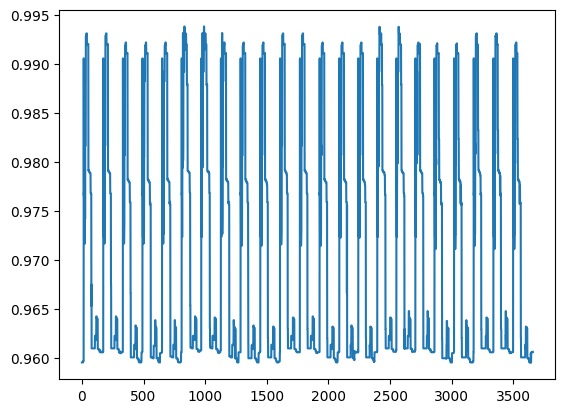

In [ ]:
ntf = [top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_incremental]
plt.plot(ntf)
mean_NTS = np.mean(ntf)
print(f'{mean_NTS:.2f}')

eps = 1e-02, mean_topeps = 0.09
eps = 2e-02, mean_topeps = 0.18
eps = 5e-02, mean_topeps = 1.00
eps = 1e-01, mean_topeps = 1.00
eps = 2e-01, mean_topeps = 1.00


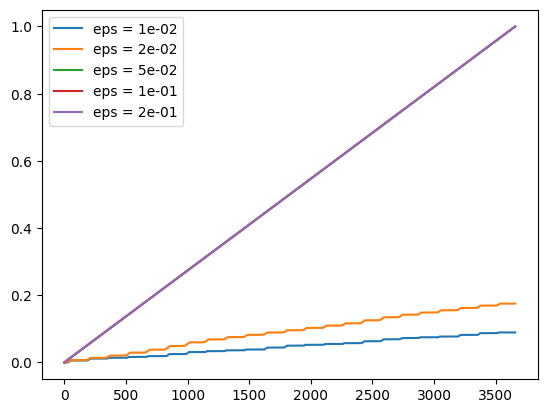

In [ ]:
for eps in [1e-2, 2e-2, 5e-2, 1e-1, 2e-1]:
    topeps = [top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_incremental]
    plt.plot(np.cumsum(topeps) / len(topeps), label=f'{eps = :.0e}')
    mean_topeps = np.mean(topeps)
    print(f'{eps = :.0e}, {mean_topeps = :.2f}')
plt.legend()
# plt.grid()

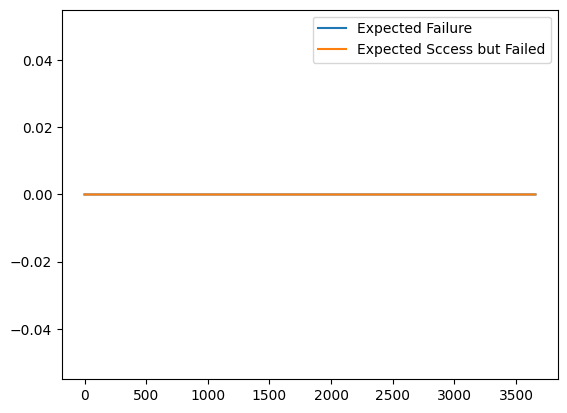

In [ ]:
ef = [max(x["yoracle"]) <= FAIL_REWARD for x in data_incremental]
esbf = [
    max(x["yoracle"]) > FAIL_REWARD
    and x["yoracle"][np.argmax(x["ypred"])] <= FAIL_REWARD
    for x in data_incremental
]
plt.plot(ef, label='Expected Failure')
plt.plot(esbf, label='Expected Sccess but Failed')
plt.legend()

Regret: 495.21585013766156


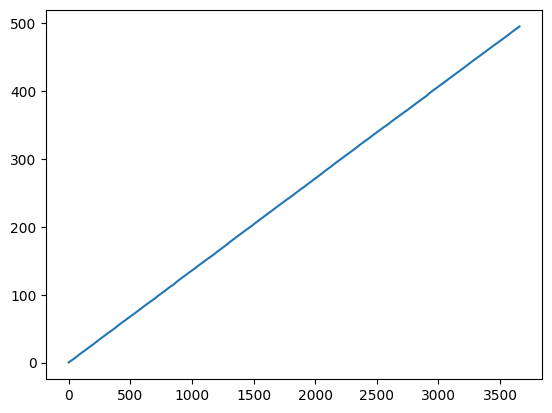

In [ ]:
regret = [max(x['yoracle']) - x["yoracle"][np.argmax(x["ypred"])] for x in data_incremental]
plt.plot(np.cumsum(regret))
print('Regret:', np.sum(regret))

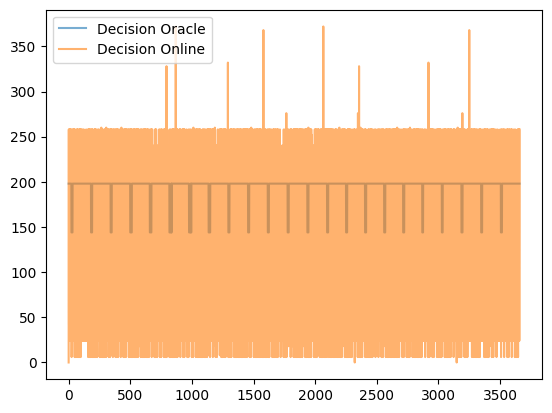

In [ ]:
plt.plot([np.argmax(x['yoracle']) for x in data_incremental], label='Decision Oracle', alpha=0.6)
plt.plot([np.argmax(x['ypred']) for x in data_incremental], label='Decision Online', alpha=0.6)
plt.legend()